In [22]:
def generate_mixed_positions(
    N,
    L,
    frac_agg,
    n_centers,
    base_sigma,
    rng,
    sigma_mode="same",
    sigma_min=0.05,
    sigma_max=0.20
):
    """
    Genera posiciones en un dominio cuadrado L x L.

    sigma_mode:
        "same"   -> todos los centros tienen sigma = base_sigma
        "random" -> cada centro tiene una sigma aleatoria entre sigma_min y sigma_max
    """

    N_agg = int(frac_agg * N)
    N_rand = N - N_agg

    # ============================================================
    # Centros de agregación
    # ============================================================

    centers = rng.uniform(
        low=-L/2,
        high=L/2,
        size=(n_centers, 2)
    )

    # ============================================================
    # Sigma de cada centro
    # ============================================================

    if sigma_mode == "same":
        sigmas = np.full(n_centers, base_sigma)

    elif sigma_mode == "random":
        sigmas = rng.uniform(
            low=sigma_min,
            high=sigma_max,
            size=n_centers
        )

    else:
        raise ValueError("sigma_mode debe ser 'same' o 'random'")

    # ============================================================
    # Neuronas agregadas
    # ============================================================

    positions_agg = []

    for i in range(N_agg):
        # Elegimos un centro al azar
        c_idx = rng.integers(0, n_centers)

        center = centers[c_idx]
        sigma = sigmas[c_idx]

        # Generamos una neurona alrededor de ese centro
        pos = rng.normal(
            loc=center,
            scale=sigma,
            size=2
        )

        # Si cae fuera del dominio, la reintentamos
        while (
            pos[0] < -L/2 or pos[0] > L/2 or
            pos[1] < -L/2 or pos[1] > L/2
        ):
            pos = rng.normal(
                loc=center,
                scale=sigma,
                size=2
            )

        positions_agg.append(pos)

    positions_agg = np.array(positions_agg)

    # ============================================================
    # Neuronas random
    # ============================================================

    positions_rand = rng.uniform(
        low=-L/2,
        high=L/2,
        size=(N_rand, 2)
    )

    # ============================================================
    # Juntar posiciones
    # ============================================================

    positions = np.vstack([positions_agg, positions_rand])

    labels = np.array(["agg"] * N_agg + ["rand"] * N_rand)

    return positions, centers, labels, sigmas



def create_distance_network(
    positions,
    r_conn,
    alpha=0.2,
    directed=False,
    rng=None
):
    """
    Crea una matriz de adyacencia A.

    Si la distancia entre dos neuronas es menor que r_conn,
    se conectan con probabilidad alpha.

    directed=False crea una red no dirigida.
    directed=True crea una red dirigida.
    """

    if rng is None:
        rng = np.random.default_rng()

    N = positions.shape[0]
    A = np.zeros((N, N), dtype=int)

    if directed:

        for i in range(N):
            for j in range(N):

                if i == j:
                    continue

                dist = np.linalg.norm(positions[i] - positions[j])

                if dist <= r_conn:
                    if rng.random() < alpha:
                        A[i, j] = 1

    else:

        for i in range(N):
            for j in range(i + 1, N):

                dist = np.linalg.norm(positions[i] - positions[j])

                if dist <= r_conn:
                    if rng.random() < alpha:
                        A[i, j] = 1
                        A[j, i] = 1

    return A

Número de neuronas inicial: 1500
Número de enlaces inicial: 86648
Grado medio inicial: 115.53066666666666
Densidad inicial: 0.07707182566155214
La red inicial no es conexa
Tamaño de la componente gigante: 1425
Fracción en componente gigante: 0.95

Después de quedarnos con la componente gigante:
Número de neuronas: 1425
Número de enlaces: 86583
Grado medio: 121.52
Densidad: 0.0853370786516854
¿Es conexa ahora?: True
Número de comunidades detectadas: 9
Tamaños de comunidades: [410, 376, 369, 110, 63, 55, 18, 14, 10]


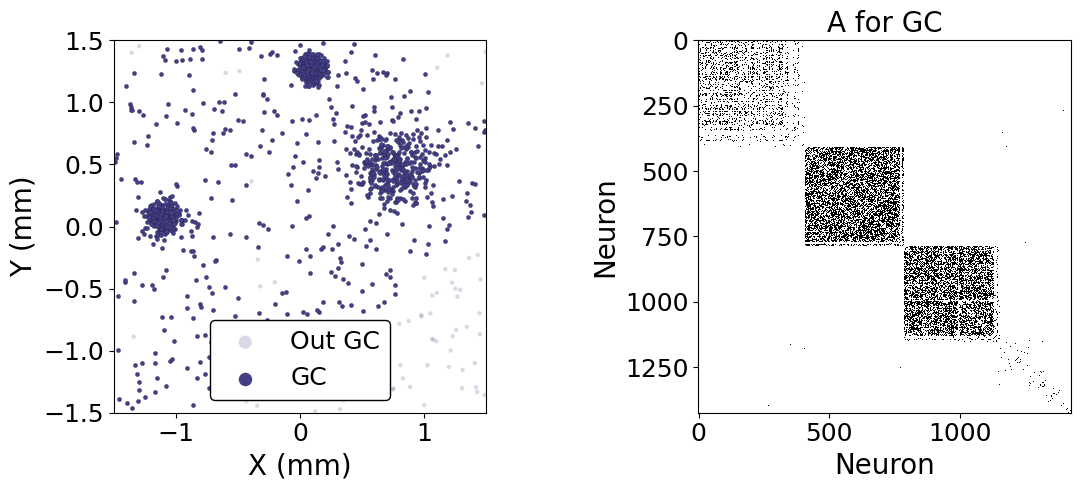

In [45]:
# Poner neuronas en un plano de LxL
## Poner un 70% agragadas y el otro 30% random
## La agregación la hacemos poniendo unos centros de menra aleatoria en la red con una cierta anchura y 
## colocando las neuronas en esos centros, el resto random en el espacio.
# Generar conexiones de acuerdo a la distancia entre neuronas con una cierta probabilidad de conexión.

import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from pypalettes import load_cmap

viridis = load_cmap("viridis")


# ============================================================
# Parámetros principales
# ============================================================

L = 3                # Tamaño del dominio L x L, en mm
N = 1500               # Número total de neuronas

frac_agg = 0.7  # Fracción de neuronas agregadas
n_centers = 3   # Número de centros de agregación
base_sigma = 0.2     # Anchura de los agregados, en mm

r_conn = 0.2   # Radio de conexión, en mm
alpha = 0.6        # Probabilidad de conexión si están dentro del radio

seed = np.random.SeedSequence().entropy
rng = np.random.default_rng(seed)


# ============================================================
# Generar posiciones: 70% agregadas + 30% random
# ============================================================

positions, centers, labels, sigmas = generate_mixed_positions(
    N=N,
    L=L,
    frac_agg=frac_agg,
    n_centers=n_centers,
    base_sigma=base_sigma,
    rng=rng,
    sigma_mode="random",   # "same" o "random"
    sigma_min=0.05,
    sigma_max=0.20
)

# ============================================================
# Crear matriz de adyacencia según distancia y probabilidad alpha
# ============================================================

A = create_distance_network(
    positions=positions,
    r_conn=r_conn,
    alpha=alpha,
    directed=False,
    rng=rng
)

# ============================================================
# Convertir a grafo de NetworkX
# ============================================================
# ============================================================
# Convertir a grafo de NetworkX y quedarse con la componente gigante
# ============================================================

# ============================================================
# Convertir a grafo de NetworkX y detectar componente gigante
# ============================================================

A_full = A.copy()
positions_full = positions.copy()
labels_full = labels.copy()
N_full = N

G_full = nx.from_numpy_array(A_full)

print("Número de neuronas inicial:", N_full)
print("Número de enlaces inicial:", G_full.number_of_edges())
print("Grado medio inicial:", np.mean([d for _, d in G_full.degree()]))
print("Densidad inicial:", nx.density(G_full))

if nx.is_connected(G_full):
    print("La red inicial es conexa")
    GC_nodes = np.arange(N_full)

else:
    GC = max(nx.connected_components(G_full), key=len)
    GC_nodes = np.array(sorted(list(GC)))

    print("La red inicial no es conexa")
    print("Tamaño de la componente gigante:", len(GC_nodes))
    print("Fracción en componente gigante:", len(GC_nodes) / N_full)

# Máscara booleana para saber qué nodos pertenecen a la CG
is_GC = np.zeros(N_full, dtype=bool)
is_GC[GC_nodes] = True

# ============================================================
# Reducir A, positions, labels y N a la componente gigante
# para TODO lo que venga después: Louvain, dinámica, etc.
# ============================================================

A = A_full[np.ix_(GC_nodes, GC_nodes)]
np.save("A_GC.npy", A)
positions = positions_full[GC_nodes]
np.save("positions_GC.npy", positions)
labels = labels_full[GC_nodes]

N_original = N_full
N = A.shape[0]

G = nx.from_numpy_array(A)

print("\nDespués de quedarnos con la componente gigante:")
print("Número de neuronas:", N)
print("Número de enlaces:", G.number_of_edges())
print("Grado medio:", np.mean([d for _, d in G.degree()]))
print("Densidad:", nx.density(G))
print("¿Es conexa ahora?:", nx.is_connected(G))

# ============================================================
# Ordenar matriz de adyacencia por comunidades
# ============================================================

# Detectar comunidades con Louvain
communities = nx.community.louvain_communities(G, seed=seed)

# Ordenar comunidades por tamaño, de mayor a menor
communities = sorted(communities, key=len, reverse=True)

# Lista de nodos ordenados por comunidad
ordered_nodes = []
community_boundaries = []

count = 0
for comm in communities:
    comm_sorted = sorted(list(comm))
    ordered_nodes.extend(comm_sorted)

    count += len(comm_sorted)
    community_boundaries.append(count)

# Reordenar matriz de adyacencia
A_ordered = A[np.ix_(ordered_nodes, ordered_nodes)]

print("Número de comunidades detectadas:", len(communities))
print("Tamaños de comunidades:", [len(c) for c in communities])


# ============================================================
# Plot conjunto: posiciones + matriz de adyacencia ordenada
# ============================================================

fig, axes = plt.subplots(
    1, 2,
    figsize=(12, 5),
    gridspec_kw={"width_ratios": [1, 1]}
)

# ============================================================
# Izquierda: distribución espacial
# ============================================================

# ============================================================
# Izquierda: distribución espacial completa
# ============================================================

ax = axes[0]

# Primero ploteamos los nodos que NO están en la CG
ax.scatter(
    positions_full[~is_GC, 0],
    positions_full[~is_GC, 1],
    s=10,
    alpha=0.2,
    color=viridis(0.1),
    label="Out GC",
    edgecolors='none'
)

# Después ploteamos encima los nodos de la CG
ax.scatter(
    positions_full[is_GC, 0],
    positions_full[is_GC, 1],
    s=10,
    alpha=1,
    color=viridis(0.1),
    label="GC", 
    edgecolors='black', 
    linewidths=0.1
)

ax.set_xlim(-L/2, L/2)
ax.set_ylim(-L/2, L/2)
ax.set_aspect("equal")

ax.set_xlabel("X (mm)", fontsize=20)
ax.set_ylabel("Y (mm)", fontsize=20)
# Legend makong bigger the dots, alph = 0.8 a to make it more visible, and frameon to make it more clear
legend = ax.legend(frameon=True, fontsize=18, loc="best", markerscale=3, framealpha = 1.0, edgecolor = "black")
ax.tick_params(labelsize=18)


# ============================================================
# Derecha: matriz de adyacencia ordenada por comunidades
# ============================================================

ax = axes[1]

im = ax.imshow(
    A_ordered,
    cmap="Greys",
    interpolation="nearest",
    origin="upper"
)

ax.set_title("A for GC", fontsize=20)
ax.set_xlabel("Neuron", fontsize = 20)
ax.set_ylabel("Neuron", fontsize = 20)
ax.tick_params(labelsize=18)
# ax.set_xticks([0, 1000, 2000])
# ax.set_xticklabels(["0", "1k", "2k"])
# ax.set_yticks([0, 1000, 2000])
# ax.set_yticklabels(["0", "1k", "2k"])

# Dibujar líneas separando comunidades
# for boundary in community_boundaries[:-1]:
#     ax.axhline(boundary - 0.5, color="red", linewidth=0.8, alpha=0.7)
#     ax.axvline(boundary - 0.5, color="red", linewidth=0.8, alpha=0.7)

plt.tight_layout()
plt.show()

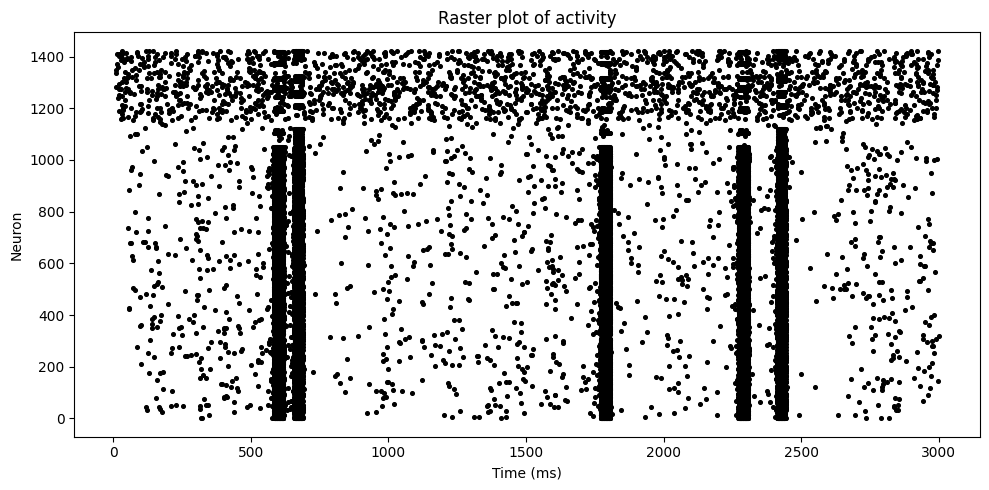

In [49]:

## Simulations
Ne = int(0.8 * N)  # Número de neuronas excitatorias
Ni = N - Ne        # Número de neuronas inhibitorias

SIM_TIME = 3000
MAX_EXC_WEIGHT =2.9
MAX_INH_WEIGHT = 0.5

W = np.hstack([
    MAX_EXC_WEIGHT * np.random.rand(N, Ne),
    -MAX_INH_WEIGHT * np.random.rand(N, Ni)
])

S = A * W
 
# Reproducibilidad opcional
np.random.seed(42)

# =========================
# Izhikevich parameters
# =========================

re = np.random.rand(Ne)
ri = np.random.rand(Ni)

a = np.concatenate([
    0.02 * np.ones(Ne),
    0.02 + 0.08 * ri
])

b = np.concatenate([
    0.2 * np.ones(Ne),
    0.25 - 0.05 * ri
])

c = np.concatenate([
    -65 + 15 * re**2,
    -65 * np.ones(Ni)
])

d = np.concatenate([
    8 - 6 * re**2,
    2 * np.ones(Ni)
])

# =========================
# MAIN SIMULATION
# =========================

NOISE_MAX = 3

v = -65 * np.ones(N)
u = b * v

firings = []

for t in range(1, SIM_TIME + 1):

    I = np.concatenate([
        NOISE_MAX * np.random.randn(Ne),
        2 * np.random.randn(Ni)
    ])

    fired = np.where(v >= 30)[0]

    if len(fired) > 0:
        firings.extend([(t, neuron) for neuron in fired])

        v[fired] = c[fired]
        u[fired] += d[fired]

        I += np.sum(S[:, fired], axis=1)

    v += 0.5 * (0.04 * v**2 + 5 * v + 140 - u + I)
    v += 0.5 * (0.04 * v**2 + 5 * v + 140 - u + I)
    u += a * (b * v - u)

firings = np.array(firings)

# =========================
# Raster plot
# =========================

plt.figure(figsize=(10, 5))

plt.scatter(
    firings[:, 0],
    firings[:, 1],
    s=7,
    color="black"
)

plt.xlabel("Time (ms)")
plt.ylabel("Neuron")
plt.title("Raster plot of activity")
plt.tight_layout()
plt.show()